# stactools-noaa-hrrr

This is a small notebook demonstrating use of this package and its generated items and collections.
It is intended to be executed from the root of this repository, since it relies on files that have been checked into this repo.

## Example items and collections

This package provides some example data, in the `examples/` directory.
You can load them with [pystac](https://github.com/stac-utils/pystac).
The item includes a custom attribute that is specific to this package.

In [1]:
from datetime import datetime, timedelta
from pathlib import Path
from pystac import Collection

import stactools.noaa_hrrr.stac
from stactools.noaa_hrrr.inventory import read_idx
from stactools.noaa_hrrr.metadata import CloudProvider, Product, Region, parse_href


root = Path().cwd().parent
collection = Collection.from_file(str(root / "examples" / "collection.json"))
item = next(collection.get_items())

## Creating items and collections

Items can be created from a `region`, `product`, `cloud_provider`, `reference_datetime`, and `forecast_hour`.

In [2]:
item = stactools.noaa_hrrr.stac.create_item(
    region=Region.conus,
    product=Product.sfc,
    cloud_provider=CloudProvider.azure,
    reference_datetime=datetime.now() - timedelta(days=7),
    forecast_hour=6,
)

The `parse_href` function can be used to parse the argument values from an `href`:

In [3]:
href = "https://noaahrrr.blob.core.windows.net/hrrr/hrrr.20240613/conus/hrrr.t11z.wrfsfcf06.grib2"
item = stactools.noaa_hrrr.create_item(**parse_href(href))

The `create_item` function will load the `.grib2.idx` sidecar file from cloud storage in order to populate the asset-level metadata.
If you already have the `.grib2.idx` file available in memory, you can use the `create_item_from_idx_df` function:

In [4]:
idx_df = read_idx(href + ".idx")

item = stactools.noaa_hrrr.stac.create_item_from_idx_df(
    idx_df=idx_df, **parse_href(href)
)

Items are added to collections using the standard pystac interface.

In [5]:
collection = stactools.noaa_hrrr.stac.create_collection(
    region=Region.conus, product=Product.sfc, cloud_provider=CloudProvider.azure
)
collection.add_item(item)

<Link rel=item target=<Item id=hrrr-conus-sfc-2024-06-13T11-FH6>>

## Use STAC metadata to load HRRR data in xarray

In [11]:
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
from pystac import ItemCollection

In [7]:
collection = Collection.from_file("../examples/collection.json")

In [8]:
# identify the grib:layers key for the wind speed variable
{
    key: info
    for key, info in collection.ext.item_assets["grib"]
    .properties["grib:layers"]
    .items()
    if "WIND" in key
}

{'WIND__10_m_above_ground__periodic_max': {'description': 'Wind Speed',
  'unit': 'm/s',
  'variable': 'WIND',
  'level': '10 m above ground',
  'forecast_layer_type': 'periodic_summary'}}

In [9]:
# function for generating a uri that GDAL can open using the /vsisubfile driver
def format_vsisubfile_path(grib_href: str, start_byte: int, byte_size: int) -> str:
    return f"/vsisubfile/{start_byte}_{byte_size},/vsicurl/{grib_href}"


# function for generating a uri that GDAL can open using the vrt:// syntax
def format_vrt_path(grib_href: str, grib_message: int) -> str:
    return f"vrt:///vsicurl/{grib_href}?bands={grib_message}"


# function to load a particular layer from all items into xarray and stack along the time dimension
def xarray_from_item_collection(item_collection: ItemCollection, grib_layer_key: str):
    item_layers = {}
    for item in item_collection:
        layer_info = item.assets["grib"].extra_fields["grib:layers"].get(grib_layer_key)
        if layer_info:
            # vrt_path = format_vrt_path(item.assets["grib"].href, layer_info["grib_message"])
            vsisubfile_path = format_vrt_path(
                item.assets["grib"].href, layer_info["grib_message"]
            )
            arr = (
                rioxarray.open_rasterio(
                    vsisubfile_path,
                    chunks={
                        "band": 1,
                        "x": -1,  # keep all x/y coordinates in the same chunk because GRIB files
                        "y": -1,  # do not have any spatial partitioning
                    },
                    use_idx="NO",
                )
                .squeeze()
                .assign_coords(
                    time=item.properties["datetime"],
                    reference_datetime=item.properties["forecast:reference_time"],
                )
                .expand_dims("time")
            )
            item_layers[item.id] = arr

    return xr.concat(item_layers.values(), dim="time").sortby("time").chunk(time=1)

In [10]:
item_collection = collection.get_all_items()
wind_ts = xarray_from_item_collection(
    item_collection, "WIND__10_m_above_ground__periodic_max"
)
wind_ts

<xarray.DataArray (time: 2, y: 1059, x: 1799)> Size: 30MB
dask.array<getitem, shape=(2, 1059, 1799), dtype=float64, chunksize=(1, 1059, 1799), chunktype=numpy.ndarray>
Coordinates:
    band                int64 8B 1
  * x                   (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.696e+06
  * y                   (y) float64 8kB 1.587e+06 1.584e+06 ... -1.587e+06
    spatial_ref         int64 8B 0
  * time                (time) <U20 160B '2024-05-10T12:00:00Z' '2024-05-10T1...
    reference_datetime  <U20 80B '2024-05-10T12:00:00Z'
Attributes: (12/15)
    GRIB_COMMENT:                        Wind speed [m/s]
    GRIB_DISCIPLINE:                     0(Meteorological)
    GRIB_ELEMENT:                        WIND
    GRIB_FORECAST_SECONDS:               0
    GRIB_IDS:                            CENTER=7(US-NCEP) SUBCENTER=0 MASTER...
    GRIB_PDS_PDTN:                       8
    ...                                  ...
    GRIB_SHORT_NAME:                     10-HTGL
    GRIB_UNIT:                           [m/s]
    GRIB_VALID_TIME:                     1715342400
    scale_factor:                        1.0
    add_offset:                          0.0
    long_name:                           WIND:10 m above ground:0-0 day max fcst

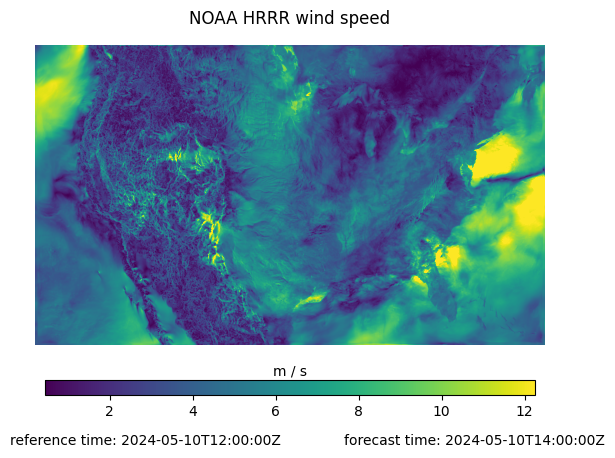

In [16]:
# plot the FH2 data
data = wind_ts.compute()

time_idx = 1
cmap = "viridis"
vmin = data.quantile(0.01)
vmax = data.quantile(0.99)
title = "NOAA HRRR wind speed"
units_label = "m / s"

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(data.isel(time=time_idx), cmap=cmap, vmin=vmin, vmax=vmax)
ax.axis("off")

# Adjust layout to reduce whitespace
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)

# Main title at the top
fig.suptitle(title, fontsize=12, y=0.92)

# reference time coordinate at the bottom left
fig.text(
    0.1,
    0.05,
    f"reference time: {data.reference_datetime.values}",
    ha="left",
    fontsize=10,
)

# forecast time coordinate at the bottom right
fig.text(
    0.95, 0.05, f"forecast time: {data.time.values[time_idx]}", ha="right", fontsize=10
)

# Horizontal colorbar below the image
cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.03])
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(units_label, fontsize=10, labelpad=3)
cbar.ax.xaxis.set_label_position("top")

plt.savefig("../noaa_hrrr_wind_speed.png")
plt.show()